# Misclassified Chord Analysis (CNN Eval Set)

Goal: For every chord the trained CNN misclassifies on the evaluation dataset, dig into
the CQT features, the audio properties and the structural trait differences between the
true class, the predicted class, and the training-set distribution.

Inputs:
- `../../evaluations/evaluations.npz` – CQT features + labels (20 samples per class)
- `../../evaluations/opus/<class>/<class>-N.ogg` – raw evaluation audio
- `../../models/model-bn-c64-c128-c256-c256-d256.keras` – trained CNN
- `../../features/opus-training.npz` – clean training CQT (used as a reference)

## 1. Setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import pickle
import random
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import seaborn as sns

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

ROOT = '../..'
MODEL_PATH = f'{ROOT}/models/model-bn-c64-c128-c256-c256-d256.keras'
EVAL_NPZ   = f'{ROOT}/evaluations/test-all.npz'
EVAL_AUDIO = f'{ROOT}/evaluations/test-all'
TRAIN_NPZ  = f'{ROOT}/features/opus-training.npz'

AUDIO_SAMPLE_RATE = 48_000
CQT_HOP_LENGTH     = 512
CQT_BINS_PER_OCTAVE = 36
CQT_OCTAVES        = 6
CQT_FMIN           = librosa.note_to_hz('C1')

N_BINS   = CQT_BINS_PER_OCTAVE * CQT_OCTAVES
BIN_FREQS = librosa.cqt_frequencies(n_bins=N_BINS, fmin=CQT_FMIN,
                                   bins_per_octave=CQT_BINS_PER_OCTAVE)
BIN_MIDI  = librosa.hz_to_midi(BIN_FREQS)
BINS_PER_NOTE = CQT_BINS_PER_OCTAVE // 12

USE_CACHE = True
CACHE_DIR = 'misclass-cache'

print('Configuration ready.')
print(f'  bins          : {N_BINS}')
print(f'  bin freq range: {BIN_FREQS[0]:.1f} Hz  –  {BIN_FREQS[-1]:.1f} Hz')
print(f'  bin midi range: {BIN_MIDI[0]:.2f}  –  {BIN_MIDI[-1]:.2f}')

Configuration ready.
  bins          : 216
  bin freq range: 32.7 Hz  –  2053.1 Hz
  bin midi range: 24.00  –  95.67


## 2. Load model, evaluation CQT, and training CQT

In [2]:
import tensorflow as tf

model = tf.keras.models.load_model(MODEL_PATH)
model.summary(print_fn=lambda s: print('  ' + s))

  Model: "sequential"
  _________________________________________________________________
   Layer (type)                Output Shape              Param #   
   batch_normalization (Batch  (None, 216, 188, 1)       864       
   Normalization)                                                  
                                                                   
   conv2d (Conv2D)             (None, 216, 188, 64)      640       
                                                                   
   max_pooling2d (MaxPooling2  (None, 108, 94, 64)       0         
   D)                                                              
                                                                   
   conv2d_1 (Conv2D)           (None, 108, 94, 128)      73856     
                                                                   
   max_pooling2d_1 (MaxPoolin  (None, 54, 47, 128)       0         
   g2D)                                                            
                          

In [3]:
with np.load(EVAL_NPZ) as d:
    eval_features = d['features'].astype(np.float32)
    eval_labels   = d['labels']
with np.load(TRAIN_NPZ) as d:
    train_features = d['features'].astype(np.float32)
    train_labels   = d['labels']

print(f'Eval CQT  : {eval_features.shape}, classes={len(np.unique(eval_labels))}')
print(f'Train CQT : {train_features.shape}, classes={len(np.unique(train_labels))}')
print(f'Eval audio dir exists : {os.path.isdir(EVAL_AUDIO)}')

Eval CQT  : (1440, 216, 188), classes=36
Train CQT : (7200, 216, 188), classes=36
Eval audio dir exists : True


## 3. Reproduce predictions

Run the clean model on the eval CQT and produce a per-sample prediction frame.

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

le = LabelEncoder()
le.fit(eval_labels)  # 36 eval classes match the model output
CLASSES = le.classes_
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

eval_pred = model.predict(np.expand_dims(eval_features, axis=-1), verbose=0)
eval_pred_idx = np.argmax(eval_pred, axis=1)
eval_true_idx = le.transform(eval_labels)
eval_pred_lbl = le.inverse_transform(eval_pred_idx)

records = []
for i in range(len(eval_labels)):
    records.append({
        'sample_id'  : i,
        'true_class' : eval_labels[i],
        'pred_class' : eval_pred_lbl[i],
        'true_idx'   : eval_true_idx[i],
        'pred_idx'   : eval_pred_idx[i],
        'confidence' : float(eval_pred[i, eval_pred_idx[i]]),
        'true_prob'  : float(eval_pred[i, eval_true_idx[i]]),
        'correct'    : eval_labels[i] == eval_pred_lbl[i],
    })
df = pd.DataFrame(records)
print(f'Overall accuracy: {df["correct"].mean():.4f}')
print(f'Total samples   : {len(df)}')
print(f'Misclassified   : {(~df["correct"]).sum()}')

# Cache: predictions + per-sample frame
os.makedirs(CACHE_DIR, exist_ok=True)
df.to_pickle(f'{CACHE_DIR}/df.pkl')
np.save(f'{CACHE_DIR}/eval_pred.npy', eval_pred)
print(f'Saved df + eval_pred -> {CACHE_DIR}')

Overall accuracy: 0.8882
Total samples   : 1440
Misclassified   : 161
Saved df + eval_pred -> misclass-cache


## 4. Per-class summary

In [5]:
rows = []
for cls in CLASSES:
    sub = df[df.true_class == cls]
    n   = len(sub)
    if n == 0:
        continue
    correct = sub['correct'].sum()
    rows.append({
        'class'      : cls,
        'n'          : n,
        'correct'    : int(correct),
        'accuracy'   : correct / n,
        'mean_conf'  : sub.confidence.mean(),
        'top_pred'   : sub.pred_class.mode().iat[0],
        'top_pred_n' : int((sub.pred_class == sub.pred_class.mode().iat[0]).sum()),
    })
per_class = pd.DataFrame(rows).sort_values('accuracy').reset_index(drop=True)
per_class

,class,n,correct,accuracy,mean_conf,top_pred,top_pred_n
0,G#_diminished_4,40,0,0.000,0.774368,B_minor_4,36
1,D_minor_4,40,7,0.175,0.838829,B_diminished_4,33
2,E_diminished_4,40,10,0.250,0.880943,D#_major_4,30
3,A#_diminished_4,40,18,0.450,0.783540,B_diminished_4,20
4,C_diminished_4,40,24,0.600,0.812410,C_diminished_4,24
5,F#_minor_4,40,35,0.875,0.876998,F#_minor_4,35
6,B_major_4,40,36,0.900,0.873640,B_major_4,36
7,E_minor_4,40,36,0.900,0.962691,E_minor_4,36
8,F_diminished_4,40,38,0.950,0.964973,F_diminished_4,38
9,A_major_4,40,39,0.975,0.988791,A_major_4,39


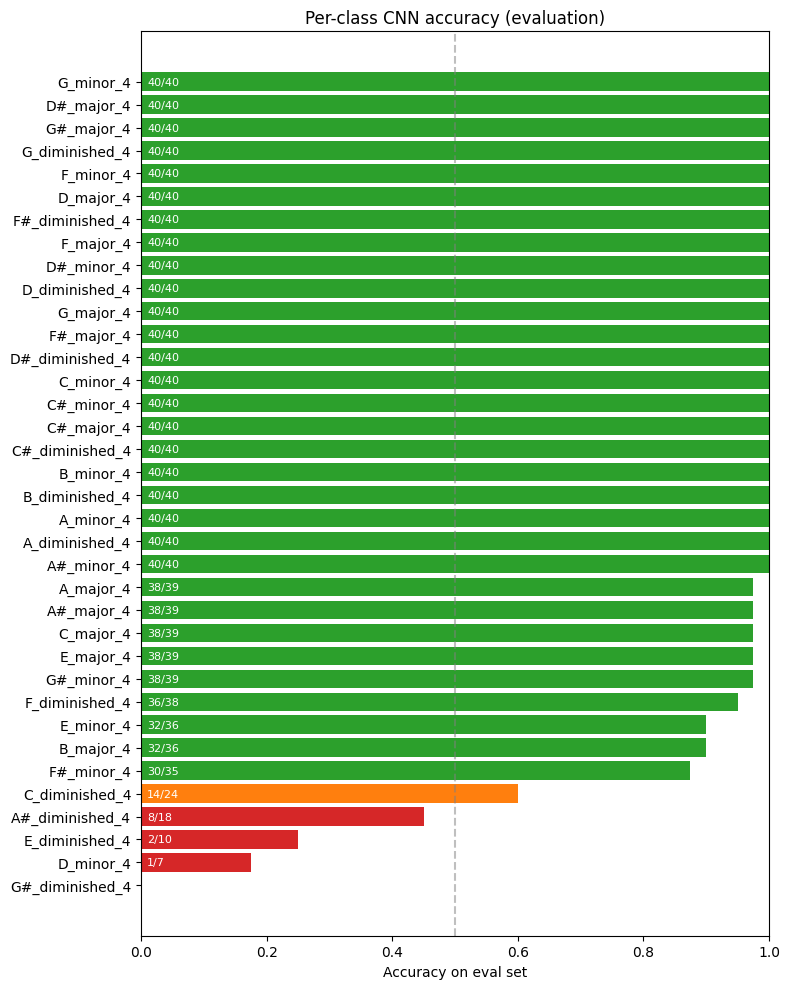

In [6]:
fig, ax = plt.subplots(figsize=(8, 10))
ordered = per_class.sort_values('accuracy')
colors  = ['tab:red' if a < 0.5 else 'tab:orange' if a < 0.85 else 'tab:green'
           for a in ordered['accuracy']]
ax.barh(ordered['class'], ordered['accuracy'], color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel('Accuracy on eval set')
ax.set_title('Per-class CNN accuracy (evaluation)')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5)
for i, (a, n) in enumerate(zip(ordered['accuracy'], ordered['correct'])):
    ax.text(0.01, i, f'{int(a*n)}/{n}', va='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

## 5. Confusion matrix & dominant confusions

Identify the worst chord-vs-chord confusions so we can drill into them.

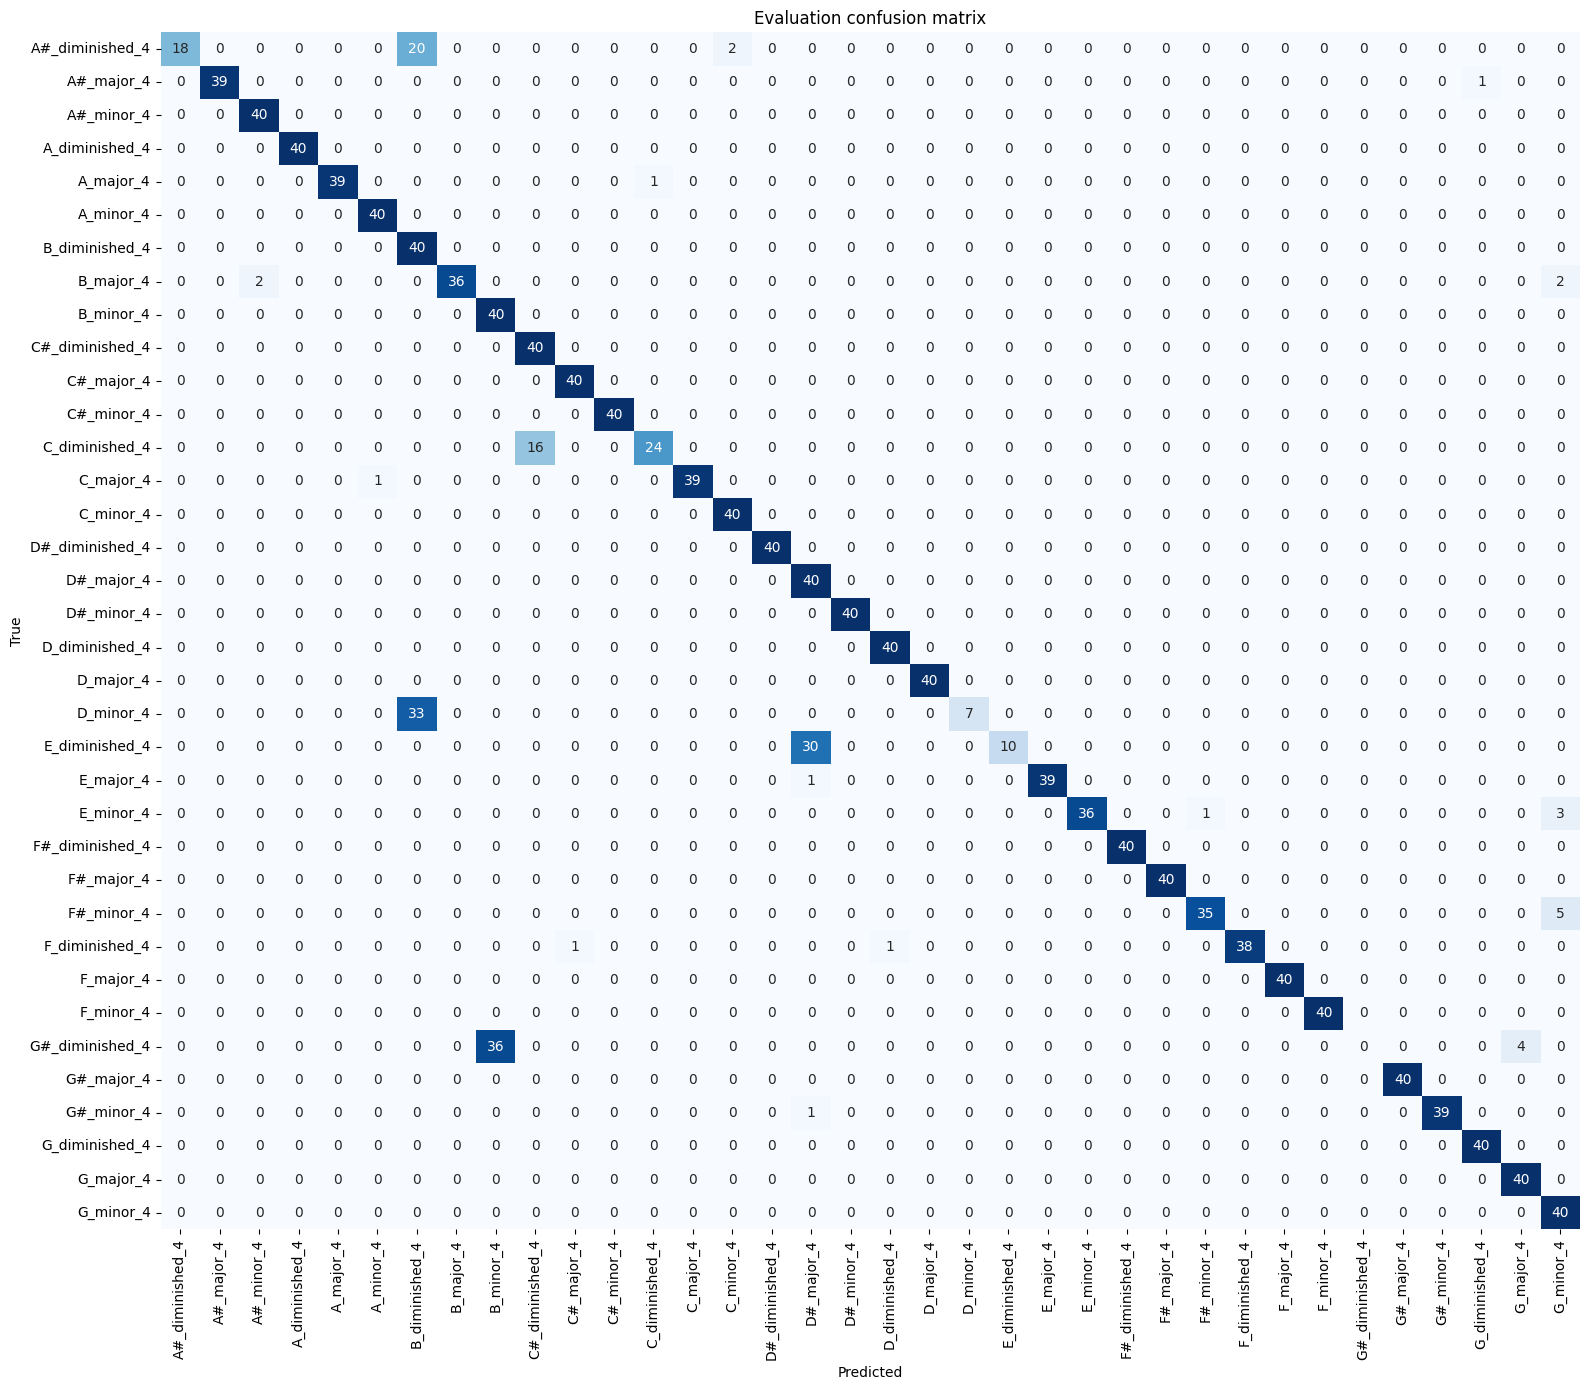

In [7]:
cm = confusion_matrix(eval_true_idx, eval_pred_idx)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Evaluation confusion matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
pairs = []
for i, t in enumerate(CLASSES):
    for j, p in enumerate(CLASSES):
        if i == j:
            continue
        c = cm[i, j]
        if c == 0:
            continue
        pairs.append({
            'true_class'      : t,
            'pred_class'      : p,
            'count'           : int(c),
            'true_total'      : int(cm[i].sum()),
            'pred_total'      : int(cm[:, j].sum()),
            'frac_of_true'    : c / max(1, cm[i].sum()),
        })
pair_df = pd.DataFrame(pairs).sort_values('count', ascending=False).reset_index(drop=True)
pair_df.head(20)

,true_class,pred_class,count,true_total,pred_total,frac_of_true
0,G#_diminished_4,B_minor_4,36,40,76,0.900
1,D_minor_4,B_diminished_4,33,40,93,0.825
2,E_diminished_4,D#_major_4,30,40,72,0.750
3,A#_diminished_4,B_diminished_4,20,40,93,0.500
4,C_diminished_4,C#_diminished_4,16,40,56,0.400
5,F#_minor_4,G_minor_4,5,40,50,0.125
6,G#_diminished_4,G_major_4,4,40,44,0.100
7,E_minor_4,G_minor_4,3,40,50,0.075
8,B_major_4,A#_minor_4,2,40,42,0.050
9,B_major_4,G_minor_4,2,40,50,0.050


## 6. Misclassified samples table

List every misclassified sample with the true / predicted / confidence.

In [9]:
mis = df[~df['correct']].copy().reset_index(drop=True)
mis['true_root'] = mis['true_class'].str.split('_').str[0]
mis['true_qual'] = mis['true_class'].str.split('_').str[1]
mis['pred_root'] = mis['pred_class'].str.split('_').str[0]
mis['pred_qual'] = mis['pred_class'].str.split('_').str[1]
mis['audio_file'] = mis.apply(lambda r: f'{r.true_class}/{r.true_class}-{r.sample_id % 20 + 1}.ogg', axis=1)
print('Top 25 lowest-confidence misclassifications:')
mis.sort_values('confidence').head(25)[
    ['sample_id','true_class','pred_class','confidence','true_prob','audio_file']]

Top 25 lowest-confidence misclassifications:


,sample_id,true_class,pred_class,confidence,true_prob,audio_file
113,1026,F_diminished_4,C#_major_4,0.301355,0.247344,F_diminished_4/F_diminished_4-7.ogg
22,98,A#_major_4,G_diminished_4,0.336983,0.254035,A#_major_4/A#_major_4-19.ogg
44,505,C_major_4,A_minor_4,0.463548,0.445707,C_major_4/C_major_4-6.ogg
26,312,B_major_4,A#_minor_4,0.470277,0.341339,B_major_4/B_major_4-13.ogg
115,1127,F#_minor_4,G_minor_4,0.503510,0.493797,F#_minor_4/F#_minor_4-8.ogg
77,839,D_minor_4,B_diminished_4,0.512131,0.473080,D_minor_4/D_minor_4-20.ogg
157,1237,G#_diminished_4,B_minor_4,0.515834,0.002438,G#_diminished_4/G#_diminished_4-18.ogg
13,22,A#_diminished_4,B_diminished_4,0.522212,0.476028,A#_diminished_4/A#_diminished_4-3.ogg
15,28,A#_diminished_4,B_diminished_4,0.528034,0.466283,A#_diminished_4/A#_diminished_4-9.ogg
109,934,E_minor_4,G_minor_4,0.531949,0.453164,E_minor_4/E_minor_4-15.ogg


## 7. CQT visualisation – dominant confusion pairs

Side-by-side: a representative misclassified sample vs an average training sample of the
same true class and vs an average of the predicted class.

In [10]:
def show_cqt(ax, cqt, title):
    im = librosa.display.specshow(
        cqt, ax=ax, x_axis='time', y_axis='cqt_note',
        sr=AUDIO_SAMPLE_RATE, fmin=CQT_FMIN,
        bins_per_octave=CQT_BINS_PER_OCTAVE, hop_length=CQT_HOP_LENGTH, cmap='magma')
    ax.set_title(title)
    return im

def mean_cqt(features, labels, cls):
    mask = labels == cls
    if mask.sum() == 0:
        return None
    return features[mask].mean(axis=0)

def worst_misclass(cls):
    sub = mis[mis.true_class == cls]
    if len(sub) == 0:
        return None
    return sub.sort_values('confidence').iloc[0]

TOP_CONFUSIONS = pair_df.head(6)[['true_class', 'pred_class', 'count']].values.tolist()
TOP_CONFUSIONS

[['G#_diminished_4', 'B_minor_4', 36],
 ['D_minor_4', 'B_diminished_4', 33],
 ['E_diminished_4', 'D#_major_4', 30],
 ['A#_diminished_4', 'B_diminished_4', 20],
 ['C_diminished_4', 'C#_diminished_4', 16],
 ['F#_minor_4', 'G_minor_4', 5]]

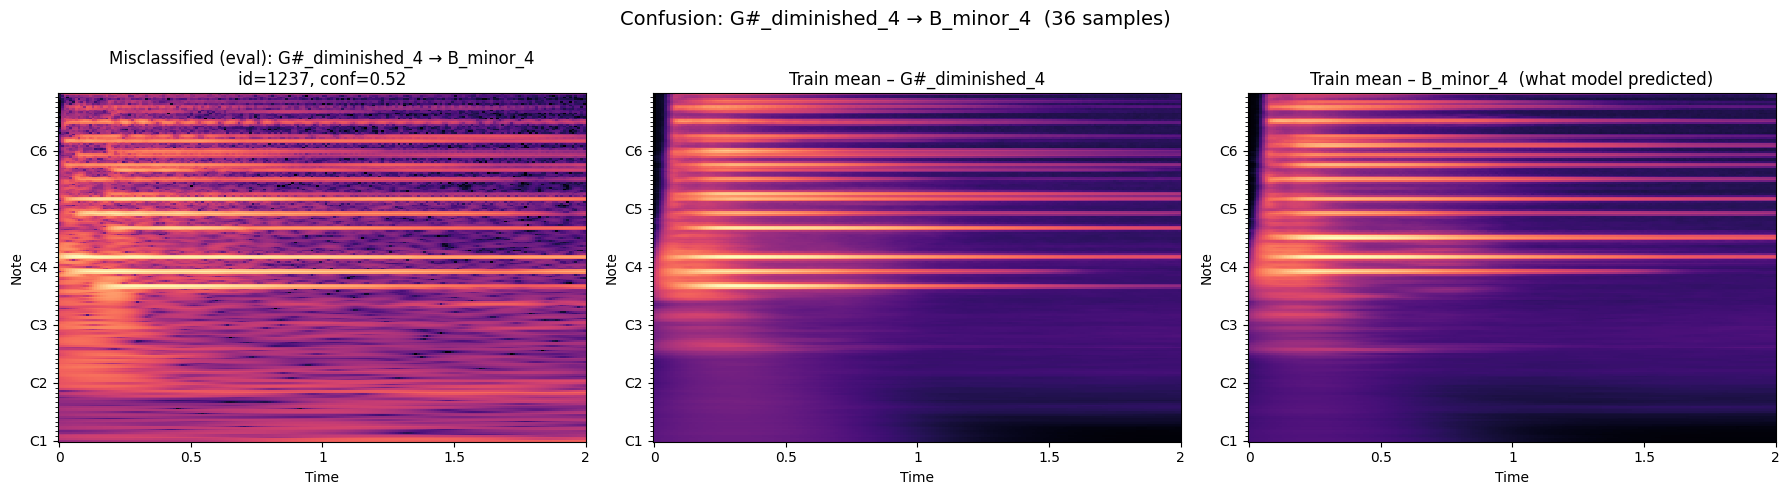

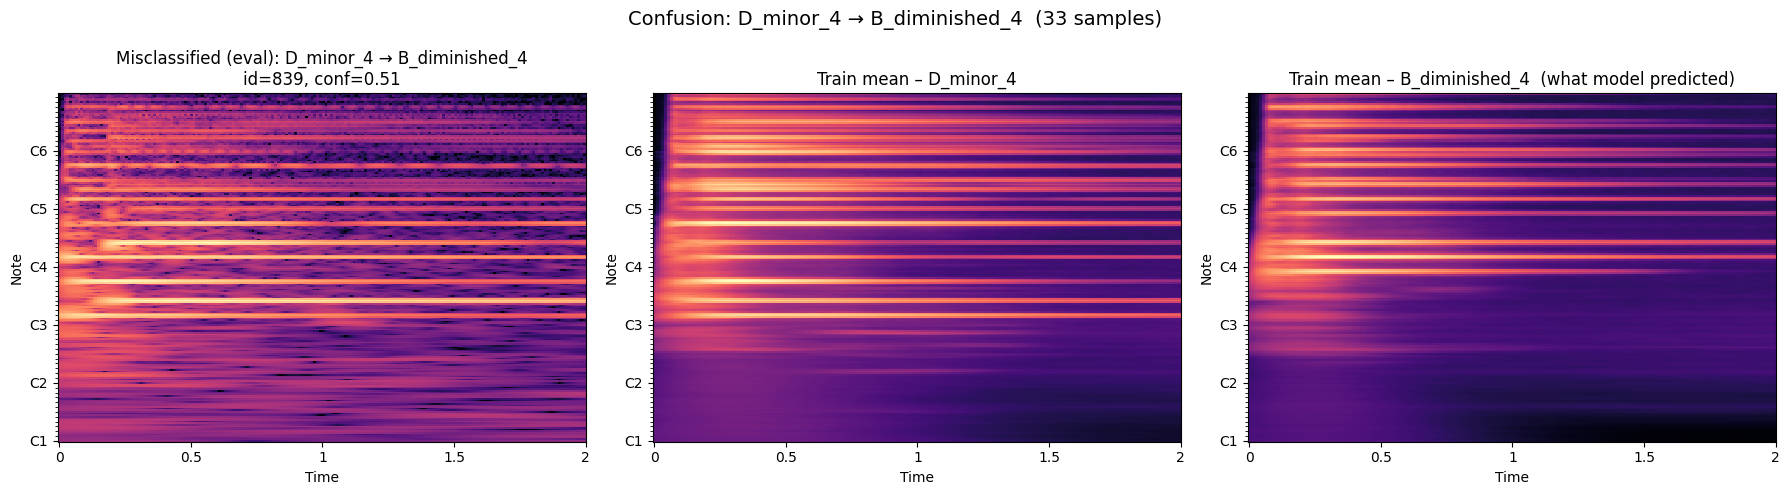

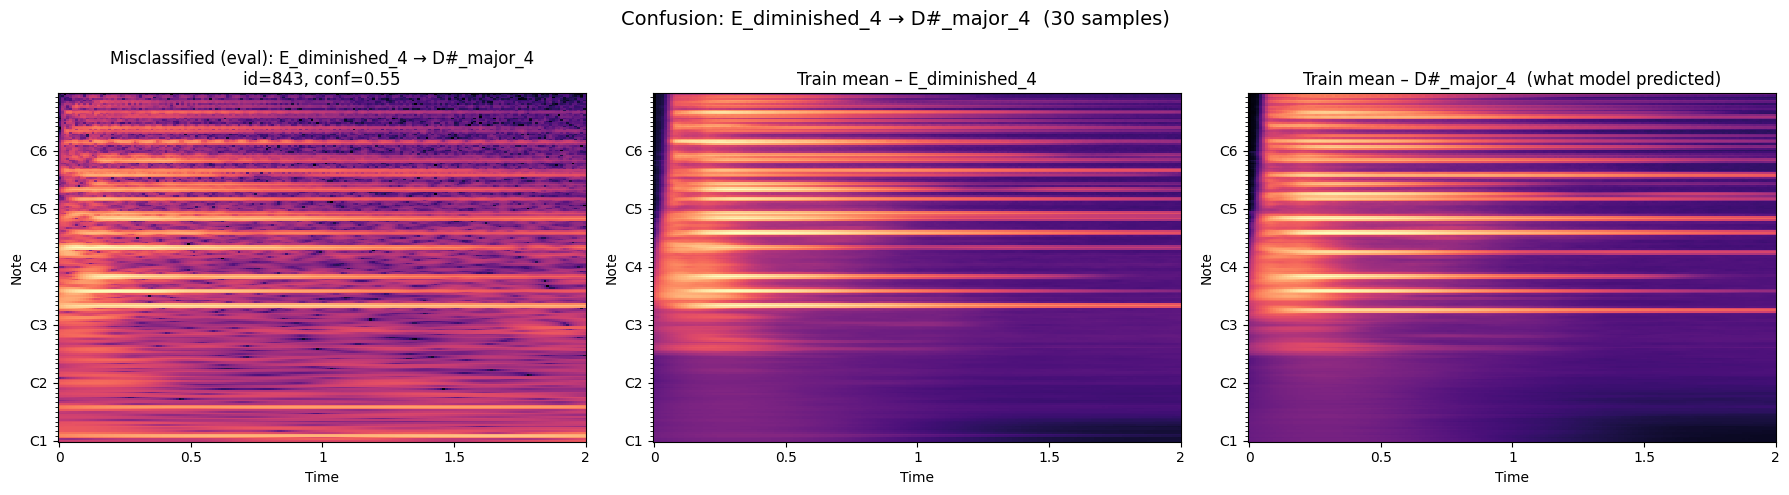

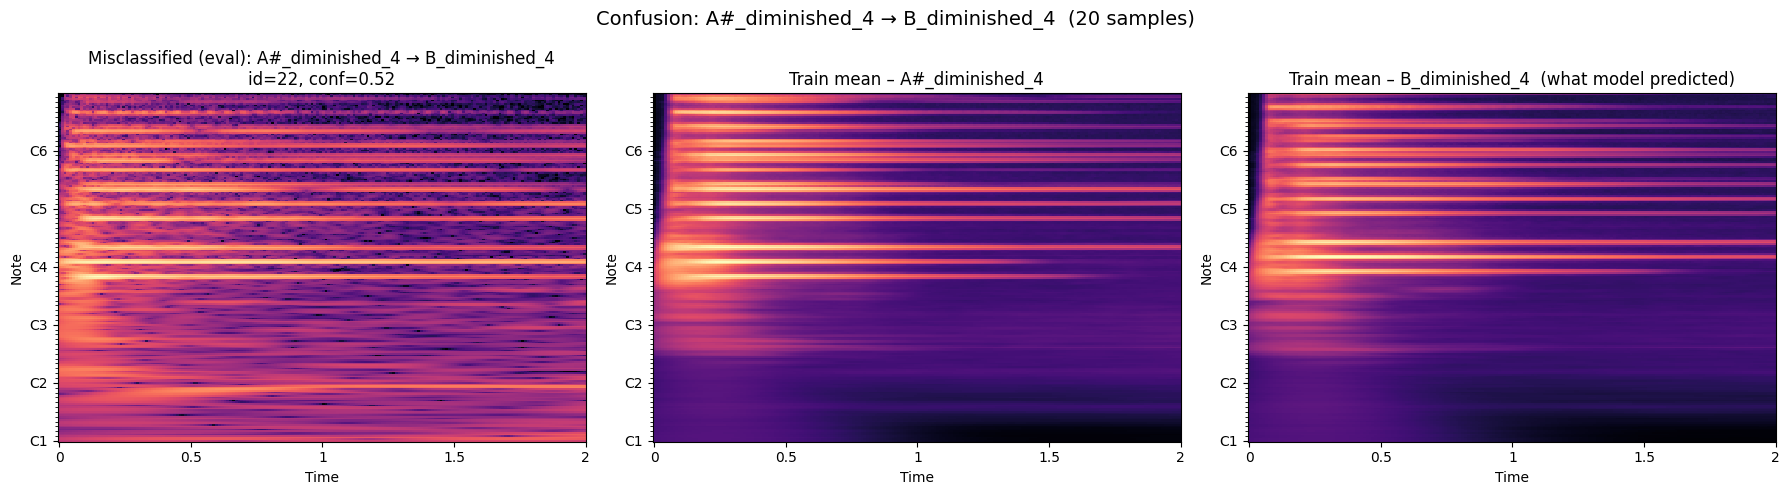

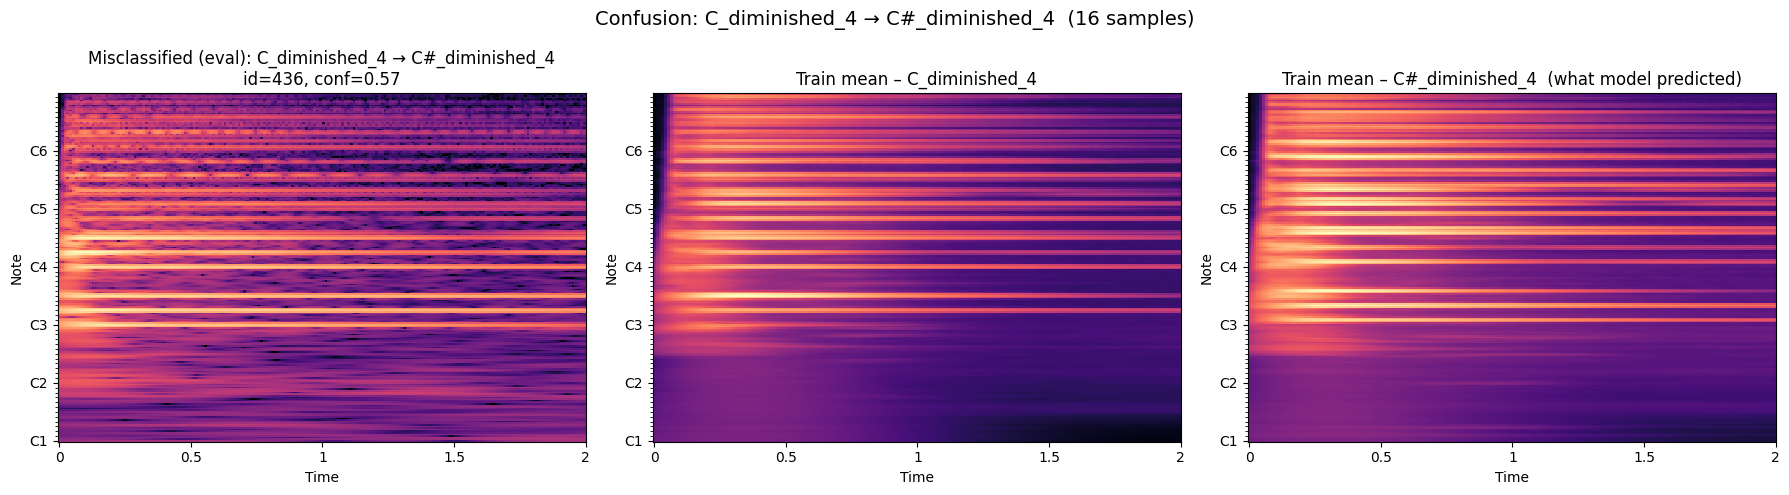

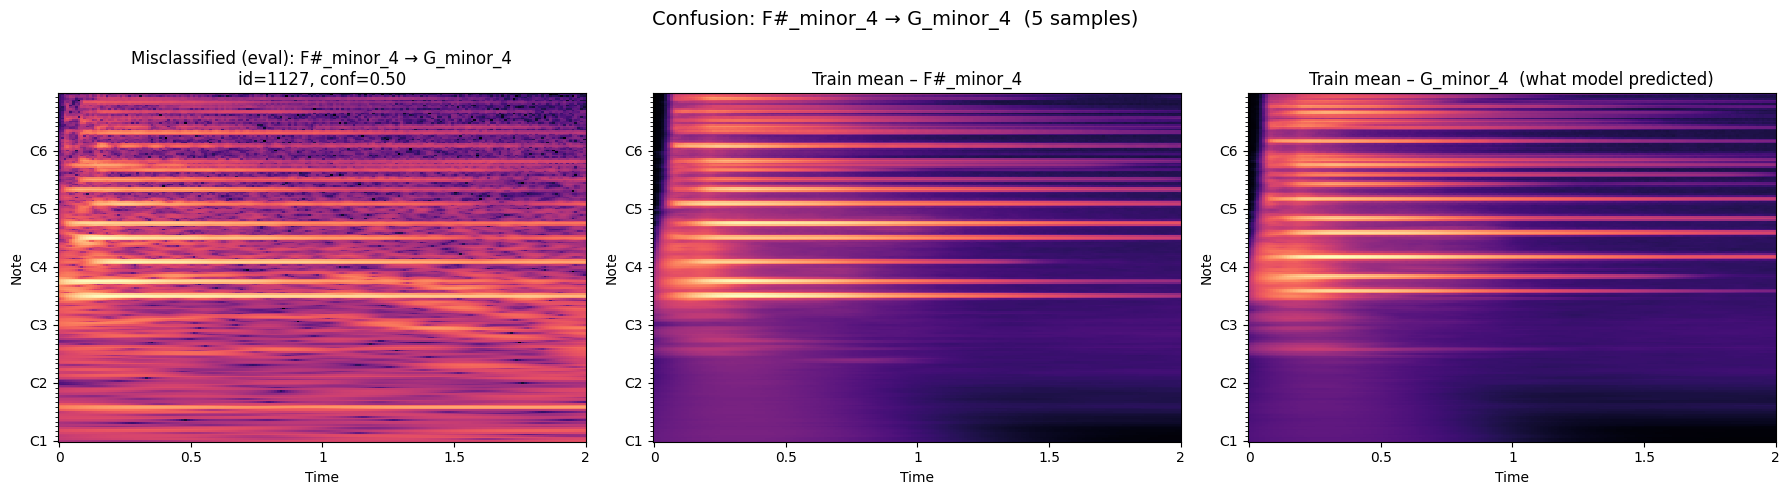

In [11]:
for t_cls, p_cls, cnt in TOP_CONFUSIONS:
    row = worst_misclass(t_cls)
    if row is None:
        continue
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    show_cqt(axes[0], eval_features[row.sample_id],
             f'Misclassified (eval): {t_cls} → {p_cls}\nid={row.sample_id}, conf={row.confidence:.2f}')
    show_cqt(axes[1], mean_cqt(train_features, train_labels, t_cls),
             f'Train mean – {t_cls}')
    show_cqt(axes[2], mean_cqt(train_features, train_labels, p_cls),
             f'Train mean – {p_cls}  (what model predicted)')
    fig.suptitle(f'Confusion: {t_cls} → {p_cls}  ({cnt} samples)', fontsize=14)
    plt.tight_layout()
    plt.show()

## 8. Mean CQT spectra per class (eval vs train)

How do the average spectrograms differ between eval and training for the failing classes?

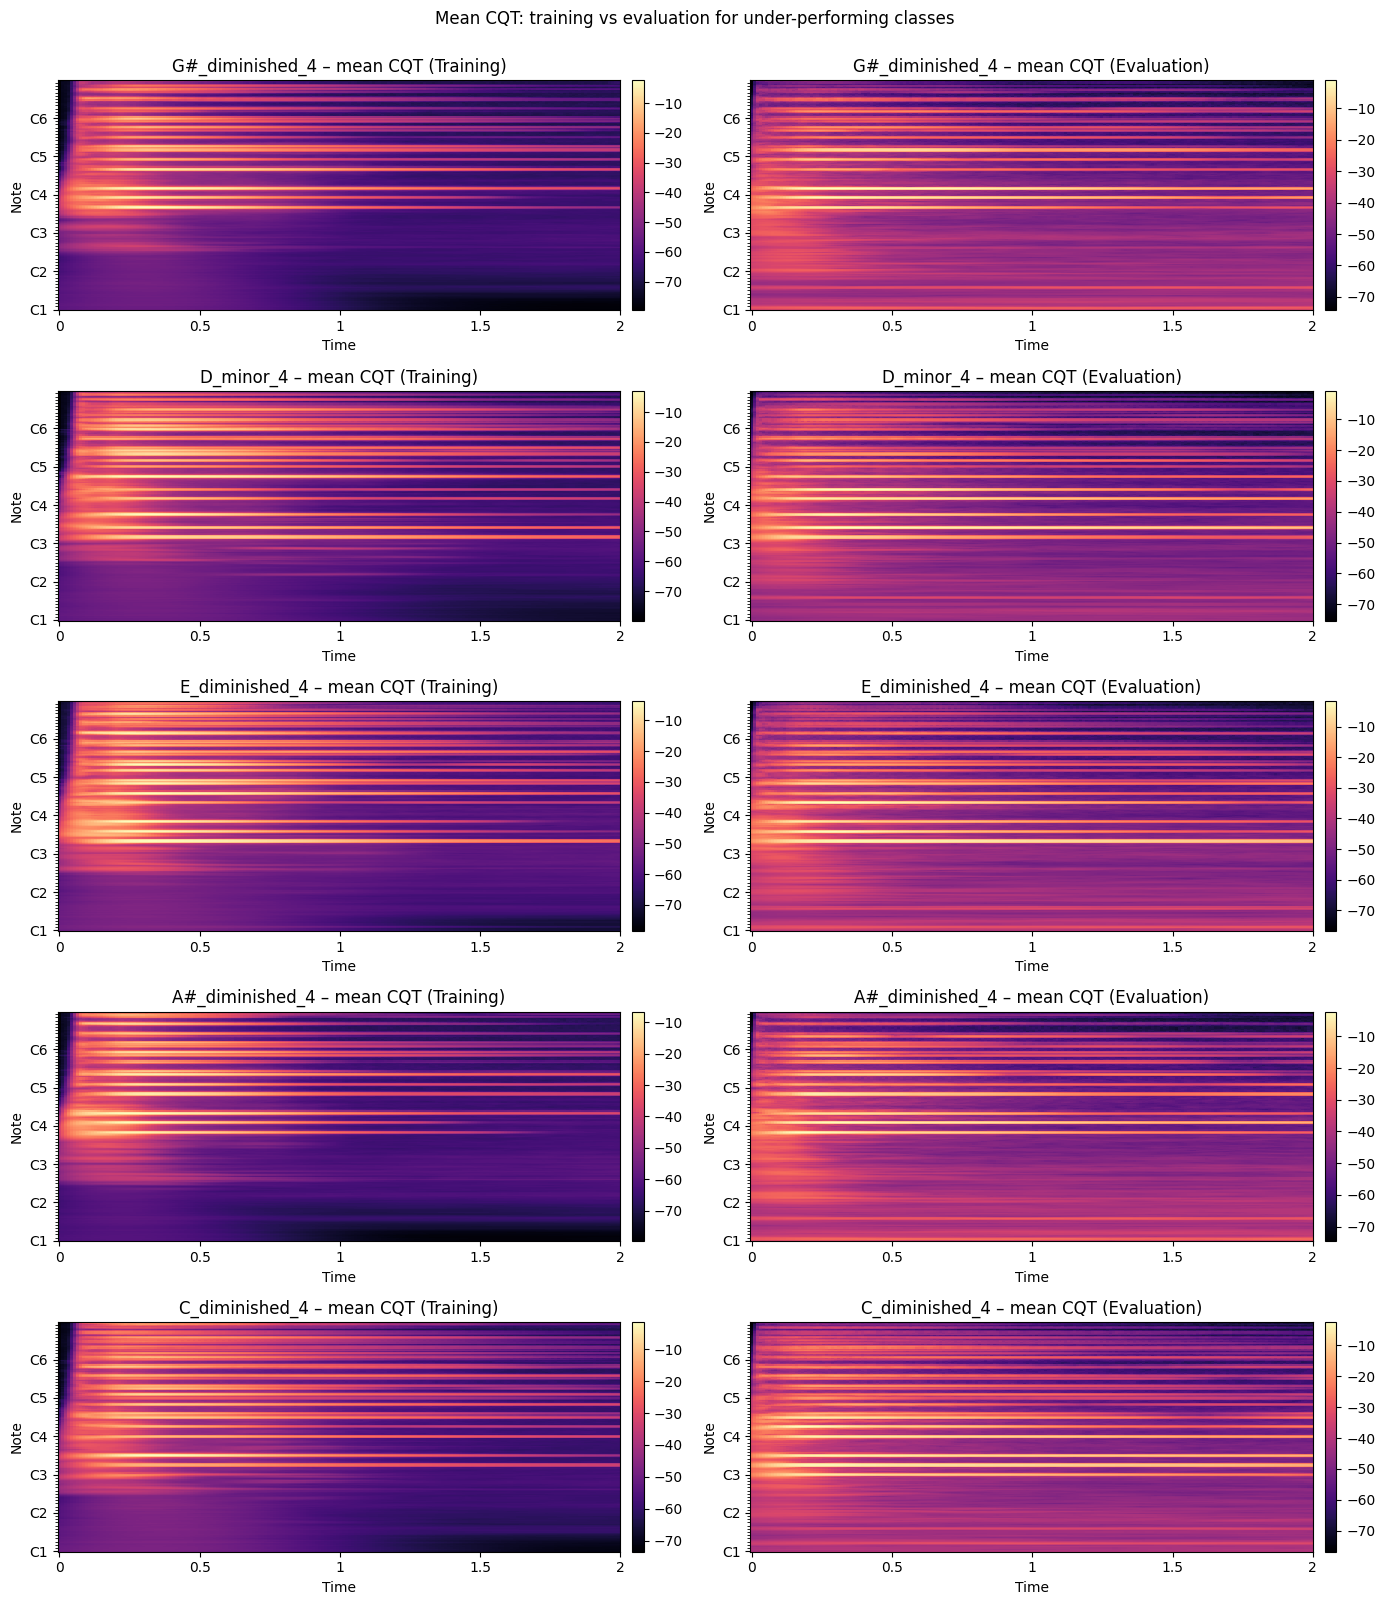

In [12]:
bad_classes = per_class[per_class['accuracy'] < 0.85]['class'].tolist()
n = len(bad_classes)
fig, axes = plt.subplots(n, 2, figsize=(14, 3.2 * n), squeeze=False)
for i, cls in enumerate(bad_classes):
    for j, (feats, lbls, name) in enumerate([
        (train_features, train_labels, 'Training'),
        (eval_features,  eval_labels,  'Evaluation'),
    ]):
        m = mean_cqt(feats, lbls, cls)
        if m is None:
            axes[i, j].set_title(f'{cls} – no data ({name})')
            axes[i, j].axis('off')
            continue
        im = librosa.display.specshow(
            m, ax=axes[i, j], x_axis='time', y_axis='cqt_note',
            sr=AUDIO_SAMPLE_RATE, fmin=CQT_FMIN,
            bins_per_octave=CQT_BINS_PER_OCTAVE, hop_length=CQT_HOP_LENGTH, cmap='magma')
        axes[i, j].set_title(f'{cls} – mean CQT ({name})')
        fig.colorbar(im, ax=axes[i, j], fraction=0.05, pad=0.02)
fig.suptitle('Mean CQT: training vs evaluation for under-performing classes', y=1.0)
plt.tight_layout()
plt.show()

## 9. Pitch-class energy profile

For each chord class, the chroma energy should peak at root, third, fifth, seventh.
If the eval profile differs from the training profile, the chord is "shifted" or "smeared"
in the recording. We collapse each CQT to a 12-bin chroma vector (sum across octaves) and
compare train vs eval distributions.

In [13]:
def chroma_from_cqt(cqt):
    """Collapse CQT (bins x frames) into a 12-bin chroma vector.

    The CQT has `n_octaves` octaves, each with 12 pitch classes, each pitch class
    spanning `BINS_PER_NOTE` adjacent bins. We mean-pool across time, then across
    octaves and within each pitch class so the result is a length-12 vector
    suitable for cosine distance and bar plots.
    """
    n_bins = cqt.shape[0]
    usable = (n_bins // BINS_PER_NOTE) * BINS_PER_NOTE            # drop trailing partial note
    cqt = cqt[:usable]                                            # (216, frames)
    n_octaves = usable // (12 * BINS_PER_NOTE)                    # 6
    cqt = cqt.reshape(n_octaves, 12, BINS_PER_NOTE, -1)           # (6, 12, 3, frames)
    return cqt.mean(axis=(0, 2, 3))                               # (12,)

def chroma_table(features, labels):
    out = {}
    for cls in np.unique(labels):
        sub = features[labels == cls]
        if len(sub) == 0:
            continue
        chromas = np.stack([chroma_from_cqt(s) for s in sub])      # (N, 12)
        out[cls] = chromas.mean(axis=0)                            # (12,)
    return out

chroma_train = chroma_table(train_features, train_labels)
chroma_eval  = chroma_table(eval_features,  eval_labels)
print('Chroma vectors computed for', len(chroma_train), 'train and', len(chroma_eval), 'eval classes.')

# Cache: chroma dictionaries
os.makedirs(CACHE_DIR, exist_ok=True)
with open(f'{CACHE_DIR}/chroma_train.pkl', 'wb') as f:
    pickle.dump(chroma_train, f)
with open(f'{CACHE_DIR}/chroma_eval.pkl', 'wb') as f:
    pickle.dump(chroma_eval, f)
print(f'Saved chroma_train, chroma_eval -> {CACHE_DIR}')

Chroma vectors computed for 36 train and 36 eval classes.
Saved chroma_train, chroma_eval -> misclass-cache


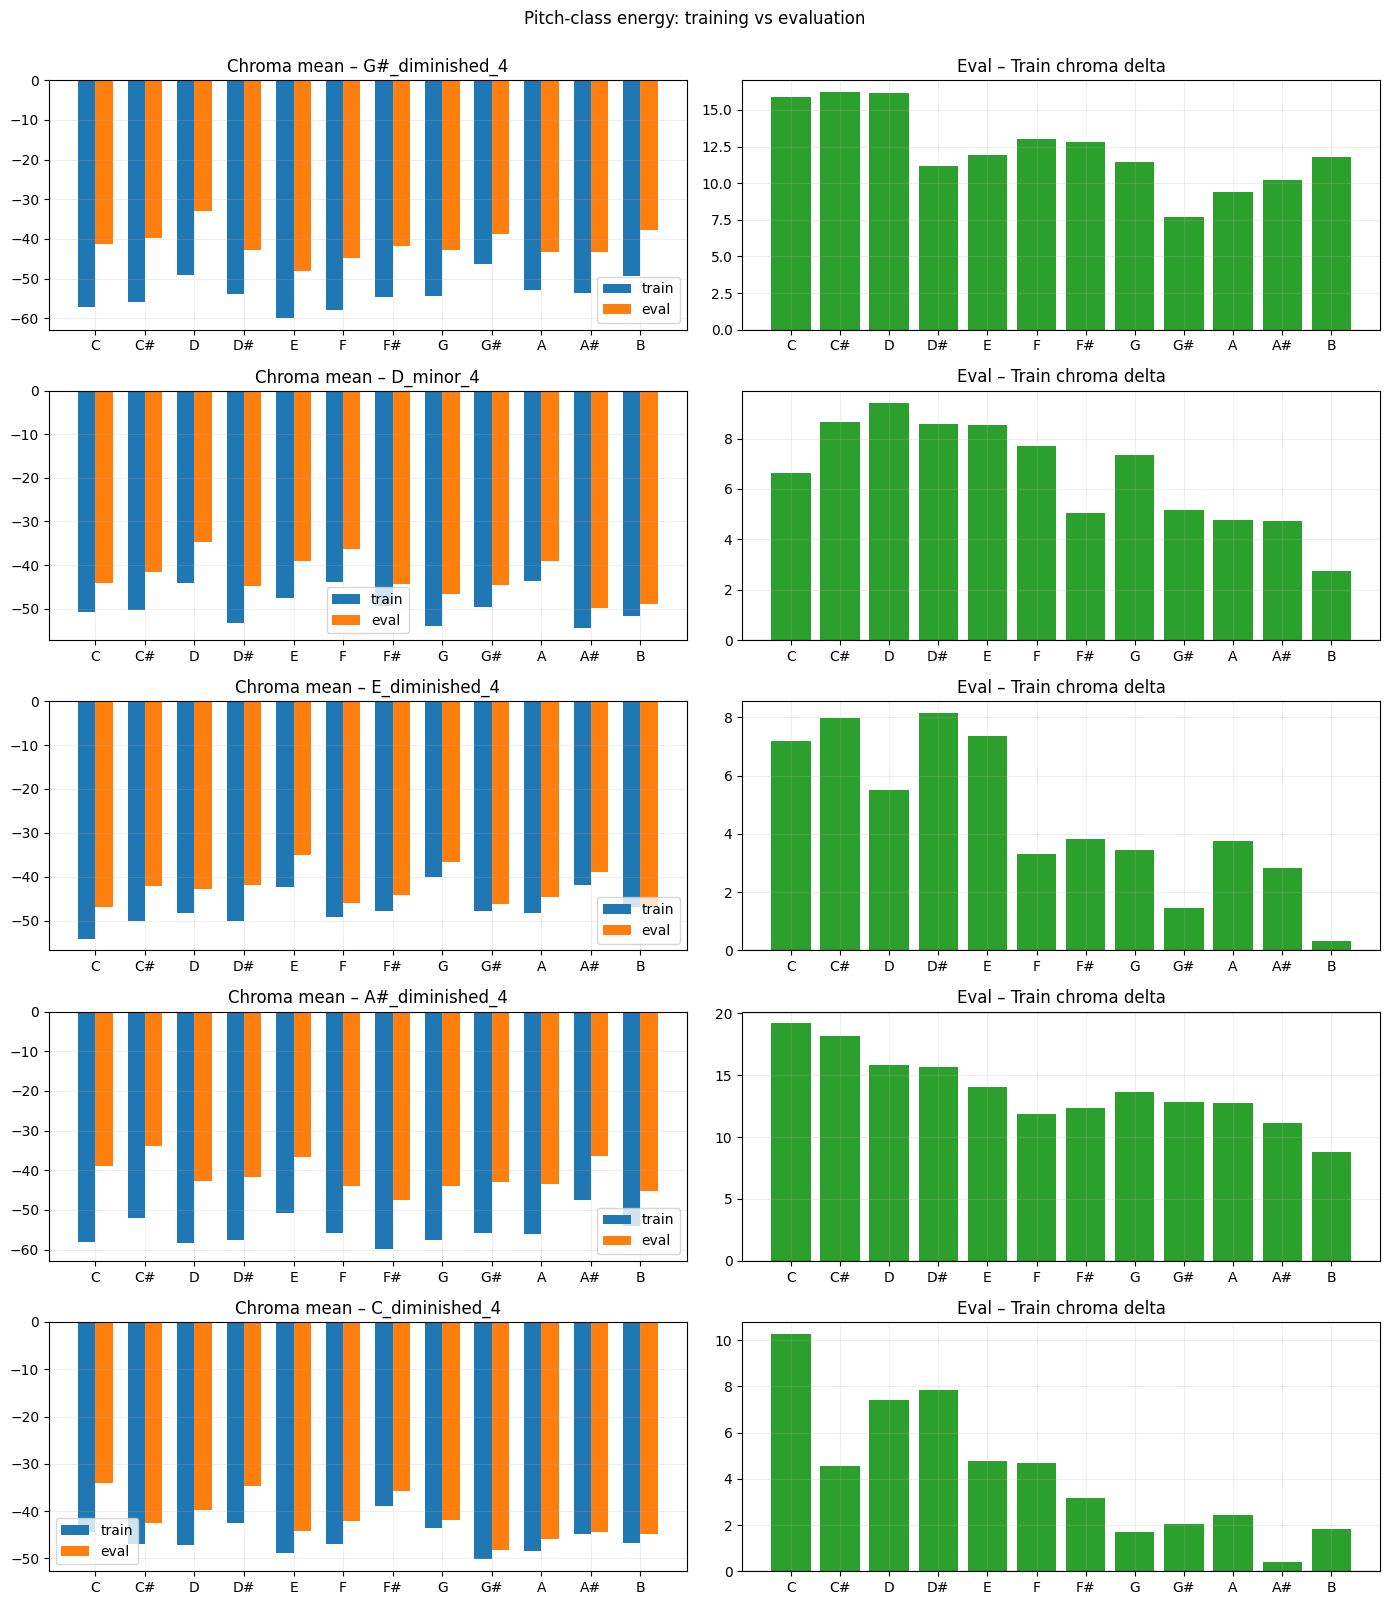

In [14]:
PITCH_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

fig, axes = plt.subplots(n, 2, figsize=(14, 3.2 * n), squeeze=False)
for i, cls in enumerate(bad_classes):
    if cls not in chroma_train or cls not in chroma_eval:
        for j in range(2):
            axes[i, j].axis('off')
        continue
    ax = axes[i, 0]
    width = 0.35
    x = np.arange(12)
    ax.bar(x - width/2, chroma_train[cls], width, label='train', color='tab:blue')
    ax.bar(x + width/2, chroma_eval[cls],  width, label='eval',  color='tab:orange')
    ax.set_xticks(x); ax.set_xticklabels(PITCH_NAMES)
    ax.set_title(f'Chroma mean – {cls}')
    ax.legend(); ax.grid(True, alpha=0.2)

    ax2 = axes[i, 1]
    diff = chroma_eval[cls] - chroma_train[cls]
    ax2.bar(x, diff, color=np.where(diff >= 0, 'tab:green', 'tab:red'))
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_xticks(x); ax2.set_xticklabels(PITCH_NAMES)
    ax2.set_title(f'Eval – Train chroma delta')
    ax2.grid(True, alpha=0.2)
fig.suptitle('Pitch-class energy: training vs evaluation', y=1.0)
plt.tight_layout()
plt.show()

## 10. Audio traits – re-load the raw .ogg

For every misclassified sample we extract a handful of audio descriptors from the raw file:
duration, RMS, peak amplitude, spectral centroid, spectral rolloff, onset count, harmonic-
noise ratio (HNR proxy via median harmonic energy over median percussive energy). These help
explain *why* the CQT looks the way it does.

In [15]:
from glob import glob
from tqdm.notebook import tqdm

def audio_path_for(true_class, sample_id):
    pattern = os.path.join(EVAL_AUDIO, true_class, f'{true_class}-{sample_id % 20 + 1}.ogg')
    if os.path.isfile(pattern):
        return pattern
    matches = glob(os.path.join(EVAL_AUDIO, true_class, f'{true_class}-*.ogg'))
    if not matches:
        return None
    matches.sort()
    return matches[sample_id % len(matches)]

def audio_descriptors(path):
    try:
        y, sr = librosa.load(path, sr=AUDIO_SAMPLE_RATE, mono=True)
    except Exception as e:
        return {'error': str(e)}
    if y.size == 0:
        return {'error': 'empty audio'}
    duration = float(librosa.get_duration(y=y, sr=sr))
    rms      = float(np.mean(librosa.feature.rms(y=y)))
    peak     = float(np.max(np.abs(y)))
    centroid = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    rolloff  = float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)))
    zcr      = float(np.mean(librosa.feature.zero_crossing_rate(y)))
    # onsets   = int(librosa.onset.onset_detect(y=y, sr=sr, hop_length=CQT_HOP_LENGTH).shape[0])
    try:
        harm, perc = librosa.effects.hpss(y)
        hn = float(np.mean(np.abs(harm)) / (np.mean(np.abs(perc)) + 1e-12))
    except Exception:
        hn = float('nan')
    return {
        'duration'  : duration,
        'rms'       : rms,
        'peak'      : peak,
        'centroid'  : centroid,
        'rolloff'   : rolloff,
        'zcr'       : zcr,
        # 'onsets'    : onsets,
        'hn_ratio'  : hn,
    }

# Sanity check
sample_path = audio_path_for(df.iloc[0].true_class, int(df.iloc[0].sample_id))
print('Example audio path:', sample_path)
audio_descriptors(sample_path)

Example audio path: ../../evaluations/test-all/A#_diminished_4/A#_diminished_4-1.ogg


{'duration': 2.34,
 'rms': 0.027039727196097374,
 'peak': 0.198577880859375,
 'centroid': 1948.2757226161748,
 'rolloff': 2940.340909090909,
 'zcr': 0.025630326704545455,
 'hn_ratio': 6.101229480998074}

In [16]:
audio_rows = []
_audio_cache = f'{CACHE_DIR}/audio_df.pkl'
if USE_CACHE and os.path.isfile(_audio_cache):
    audio_df = pd.read_pickle(_audio_cache)
    print(f'Loaded cached audio_df ({len(audio_df)} rows) from {_audio_cache}')
else:
    for r in tqdm(df.itertuples(), total=len(df), desc='Audio descriptors'):
        p = audio_path_for(r.true_class, int(r.sample_id))
        if p is None:
            continue
        desc = audio_descriptors(p)
        desc.update({
            'sample_id' : int(r.sample_id),
            'true_class': r.true_class,
            'pred_class': r.pred_class,
            'correct'   : bool(r.correct),
            'confidence': float(r.confidence),
            'audio_file': p,
        })
        audio_rows.append(desc)
    audio_df = pd.DataFrame(audio_rows)
    os.makedirs(CACHE_DIR, exist_ok=True)
    audio_df.to_pickle(_audio_cache)
    print(f'Saved audio_df ({len(audio_df)} rows) -> {_audio_cache}')
audio_df.head()

Loaded cached audio_df (1440 rows) from misclass-cache/audio_df.pkl


,duration,rms,peak,centroid,rolloff,zcr,onsets,hn_ratio,sample_id,true_class,pred_class,correct,confidence,audio_file
0,2.34,0.027040,0.198578,1948.275723,2940.340909,0.025630,4,6.101229,0,A#_diminished_4,A#_diminished_4,True,0.995796,../../evaluations/test-all/A#_diminished_4/A#_...
1,2.28,0.027092,0.225861,1910.663089,2789.719626,0.025804,5,5.874763,1,A#_diminished_4,A#_diminished_4,True,0.706353,../../evaluations/test-all/A#_diminished_4/A#_...
2,2.22,0.027759,0.264832,1901.430809,2651.241029,0.024734,1,5.892444,2,A#_diminished_4,B_diminished_4,False,0.799413,../../evaluations/test-all/A#_diminished_4/A#_...
3,2.22,0.027377,0.265350,1887.377922,2584.629187,0.024788,3,5.978909,3,A#_diminished_4,A#_diminished_4,True,0.854085,../../evaluations/test-all/A#_diminished_4/A#_...
4,2.22,0.027868,0.211121,1877.529120,2494.916268,0.026180,2,5.479200,4,A#_diminished_4,B_diminished_4,False,0.942553,../../evaluations/test-all/A#_diminished_4/A#_...


In [17]:
desc_cols = ['duration', 'rms', 'peak', 'centroid', 'rolloff', 'zcr', 'hn_ratio'] # 'onsets'
summary = audio_df.groupby('correct')[desc_cols].agg(['mean', 'std', 'median']).round(4)
summary

duration                    rms                    peak          \
            mean     std median    mean     std  median    mean     std   
correct                                                                   
False     2.2781  0.0711   2.28  0.0345  0.0048  0.0358  0.2490  0.0369   
True      2.2822  0.0730   2.28  0.0312  0.0050  0.0330  0.2356  0.0405   

                  centroid  ...               rolloff                       \
         median       mean  ...     median       mean       std     median   
correct                     ...                                              
False    0.2504  1700.8665  ...  1686.7612  2194.9711  684.2857  2045.0060   
True     0.2342  1794.1156  ...  1734.1110  2516.6726  817.7072  2238.3908   

            zcr                 hn_ratio                 
           mean     std  median     mean    std  median  
correct                                                  
False    0.0210  0.0026  0.0202   6.0834  1.469  5.8924  
True     0.0224  0.0037  0.0215   5.7495  1.331  5.4037  

[2 rows x 21 columns]

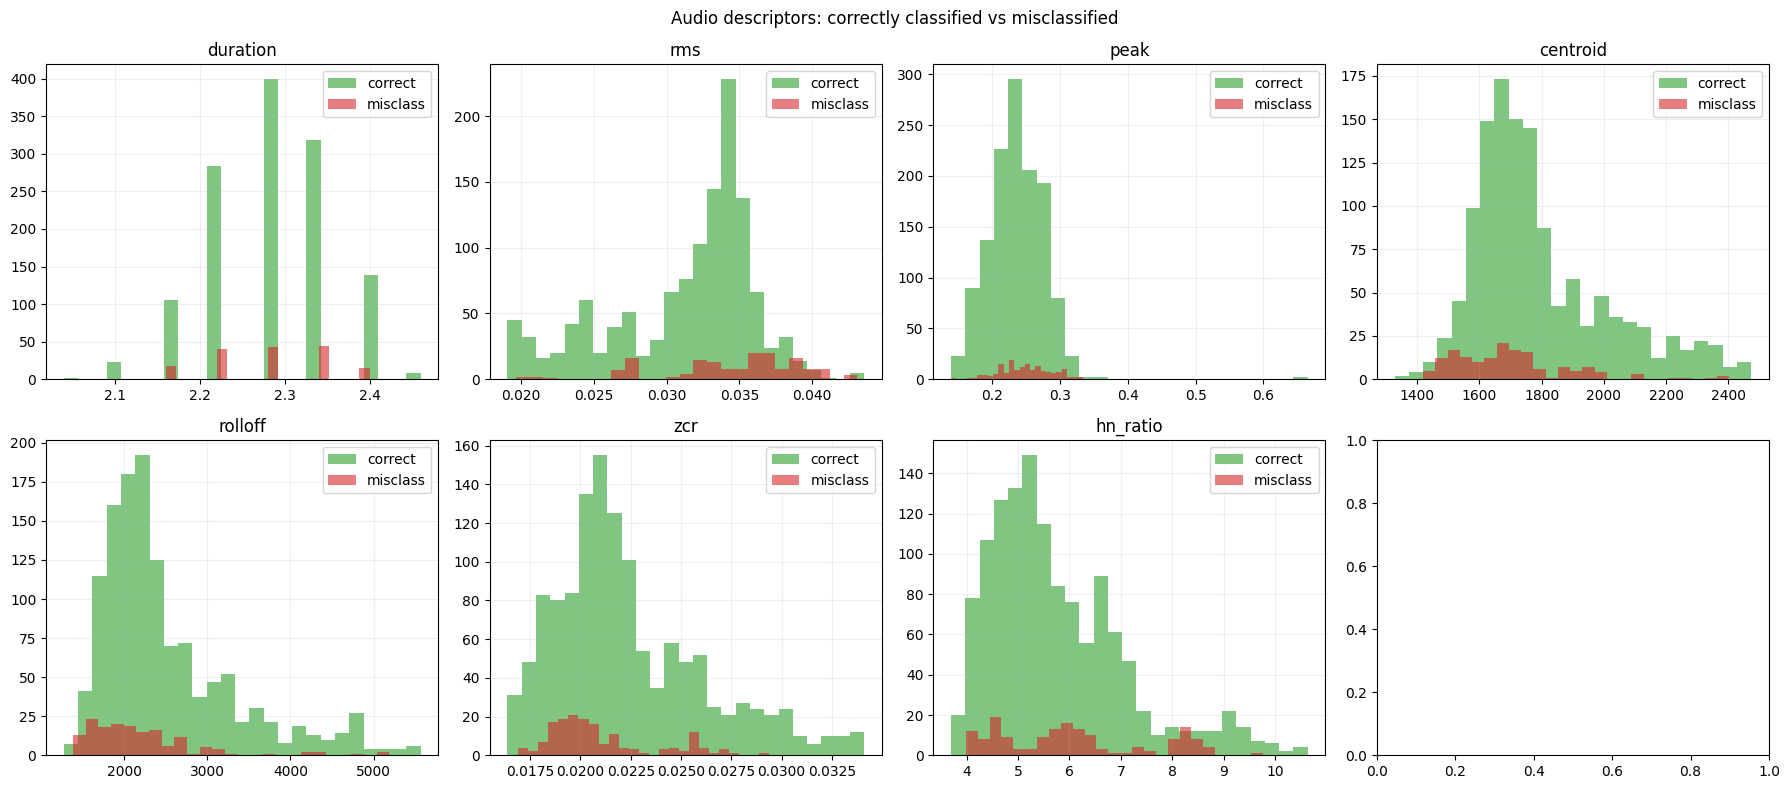

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, desc_cols):
    ax.hist(audio_df[audio_df.correct][col].dropna(), bins=25, alpha=0.6, label='correct', color='tab:green')
    ax.hist(audio_df[~audio_df.correct][col].dropna(), bins=25, alpha=0.6, label='misclass', color='tab:red')
    ax.set_title(col)
    ax.legend()
    ax.grid(True, alpha=0.2)
fig.suptitle('Audio descriptors: correctly classified vs misclassified')
plt.tight_layout()
plt.show()

### Per-class audio-trait snapshot for the worst classes

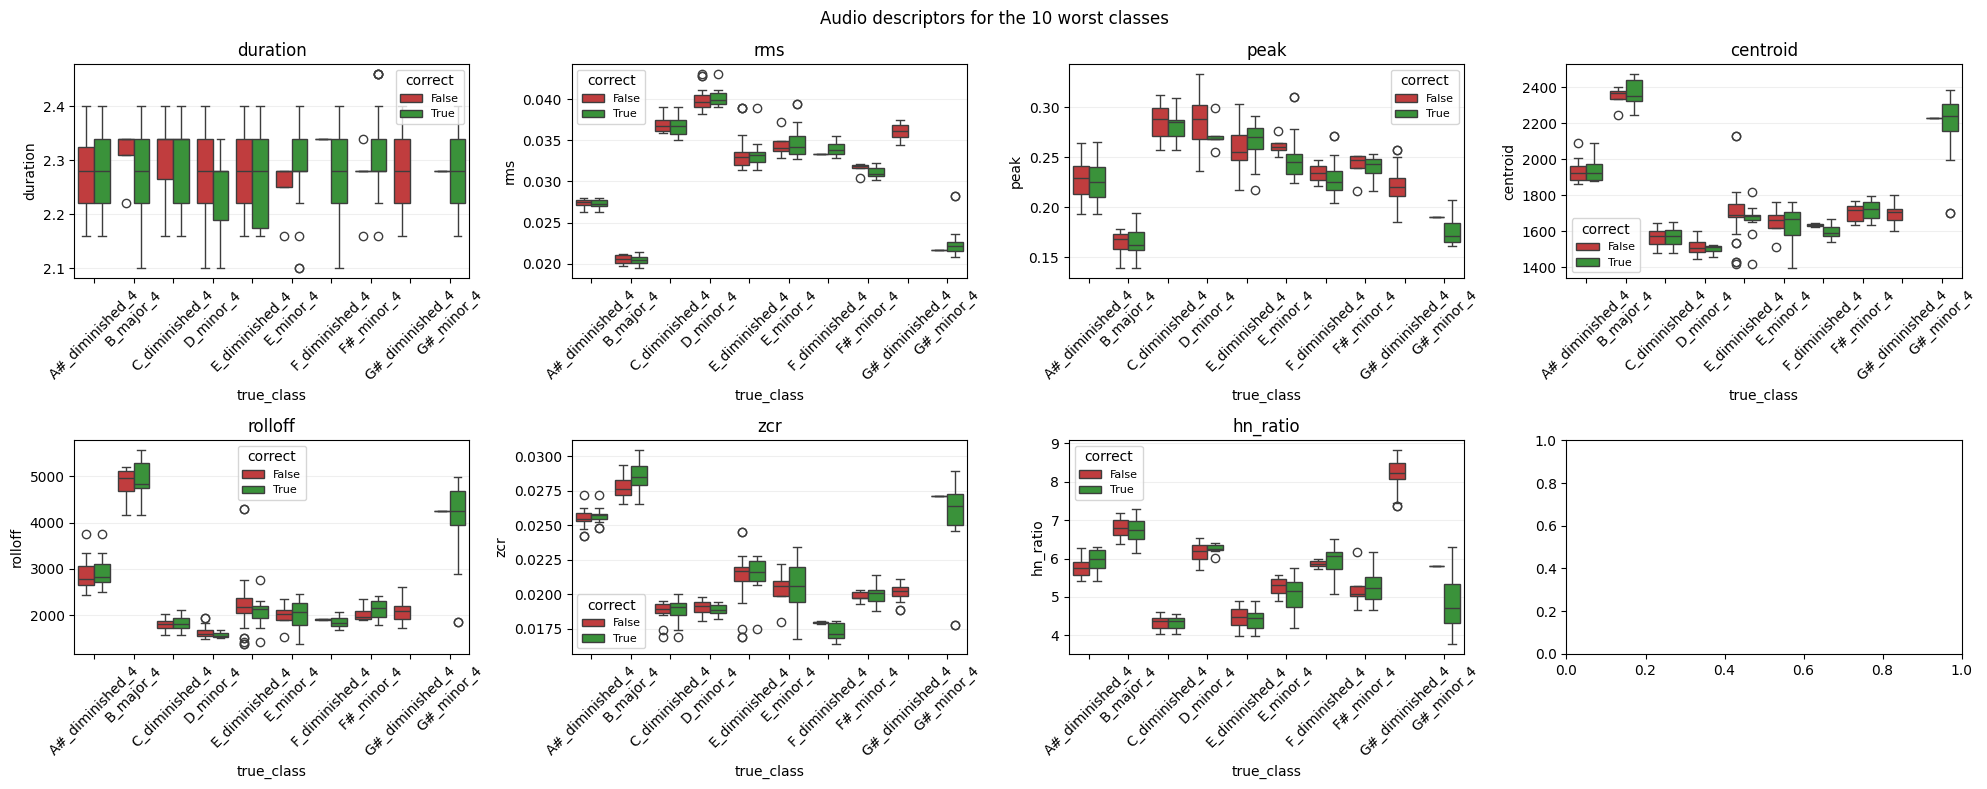

In [19]:
worse = per_class.sort_values('accuracy').head(10)['class'].tolist()
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for ax, col in zip(axes, desc_cols):
    sub = audio_df[audio_df.true_class.isin(worse)]
    sns.boxplot(data=sub, x='true_class', y=col, hue='correct', ax=ax,
                palette={True: 'tab:green', False: 'tab:red'})
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(col)
    ax.grid(True, axis='y', alpha=0.2)
    ax.legend(title='correct', fontsize=8)
fig.suptitle('Audio descriptors for the 10 worst classes')
plt.tight_layout()
plt.show()

## 11. CQT statistics vs class accuracy

For every sample we compute a few CQT statistics and correlate them with whether the
model got it right. This surfaces traits that make a sample "hard".

In [20]:
def cqt_stats(cqt):
    flat = cqt.flatten()
    return {
        'cqt_mean'     : float(cqt.mean()),
        'cqt_std'      : float(cqt.std()),
        'cqt_min'      : float(cqt.min()),
        'cqt_max'      : float(cqt.max()),
        'cqt_energy'   : float(np.mean(10 ** (cqt / 20))),  # back to linear, then mean
        'cqt_zero_pct' : float((cqt <= -80).mean()),        # silence bins
    }

_cqt_cache = f'{CACHE_DIR}/cqt_df.pkl'
if USE_CACHE and os.path.isfile(_cqt_cache):
    cqt_df = pd.read_pickle(_cqt_cache)
    print(f'Loaded cached cqt_df ({len(cqt_df)} rows) from {_cqt_cache}')
else:
    cqt_rows = []
    for r in df.itertuples():
        s = cqt_stats(eval_features[r.sample_id])
        s.update({'sample_id': int(r.sample_id),
                  'true_class': r.true_class, 'correct': bool(r.correct)})
        cqt_rows.append(s)
    cqt_df = pd.DataFrame(cqt_rows)
    os.makedirs(CACHE_DIR, exist_ok=True)
    cqt_df.to_pickle(_cqt_cache)
    print(f'Saved cqt_df ({len(cqt_df)} rows) -> {_cqt_cache}')

stat_cols = ['cqt_mean', 'cqt_std', 'cqt_min', 'cqt_max', 'cqt_energy', 'cqt_zero_pct']
cqt_df.groupby('correct')[stat_cols].agg(['mean', 'std']).round(3)

Loaded cached cqt_df (1440 rows) from misclass-cache/cqt_df.pkl


cqt_mean        cqt_std        cqt_min      cqt_max      cqt_energy  \
            mean    std    mean    std    mean  std    mean  std       mean   
correct                                                                       
False    -42.017  2.984  13.131  0.814   -80.0  0.0    -0.0  0.0      0.029   
True     -42.496  2.856  13.010  0.834   -80.0  0.0    -0.0  0.0      0.027   

               cqt_zero_pct         
           std         mean    std  
correct                             
False    0.005        0.002  0.002  
True     0.005        0.002  0.001

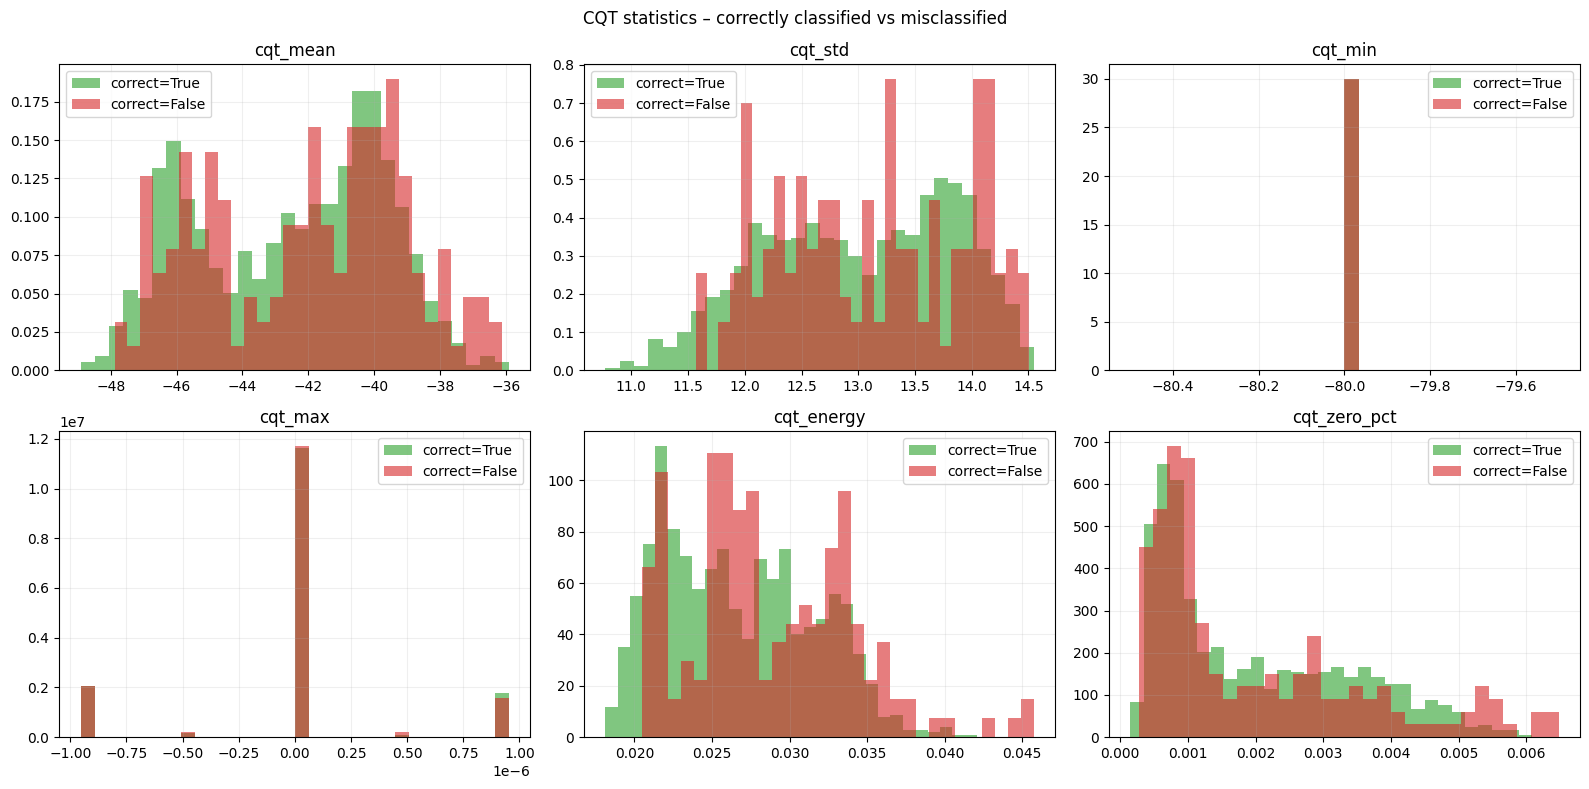

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, stat_cols):
    for ok, color in [(True, 'tab:green'), (False, 'tab:red')]:
        ax.hist(cqt_df[cqt_df.correct == ok][col], bins=30, alpha=0.6,
                label=f'correct={ok}', color=color, density=True)
    ax.set_title(col)
    ax.grid(True, alpha=0.2)
    ax.legend()
fig.suptitle('CQT statistics – correctly classified vs misclassified')
plt.tight_layout()
plt.show()

## 12. Similarity between misclassified sample and predicted class

If the misclassified sample's chroma is closer to the predicted class than to the true
class, the recording probably really does sound like the predicted chord. Otherwise the
model is making a mistake.

In [22]:
from scipy.spatial.distance import cosine

def chroma_dist(a, b):
    # chroma vectors are length 12 (after chroma_from_cqt collapse)
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    return float(cosine(a + 1e-9, b + 1e-9))

_sim_cache = f'{CACHE_DIR}/sim_df.pkl'
if USE_CACHE and os.path.isfile(_sim_cache):
    sim_df = pd.read_pickle(_sim_cache)
    print(f'Loaded cached sim_df ({len(sim_df)} rows) from {_sim_cache}')
else:
    sim_rows = []
    for r in df.itertuples():
        sample_chroma = chroma_from_cqt(eval_features[r.sample_id])
        true_chroma   = chroma_train.get(r.true_class)
        pred_chroma   = chroma_train.get(r.pred_class)
        if true_chroma is None or pred_chroma is None:
            continue
        sim_rows.append({
            'sample_id'   : int(r.sample_id),
            'true_class'  : r.true_class,
            'pred_class'  : r.pred_class,
            'correct'     : bool(r.correct),
            'dist_true'   : chroma_dist(sample_chroma, true_chroma),
            'dist_pred'   : chroma_dist(sample_chroma, pred_chroma),
            'pred_closer' : chroma_dist(sample_chroma, pred_chroma) < chroma_dist(sample_chroma, true_chroma),
        })
    sim_df = pd.DataFrame(sim_rows)
    os.makedirs(CACHE_DIR, exist_ok=True)
    sim_df.to_pickle(_sim_cache)
    print(f'Saved sim_df ({len(sim_df)} rows) -> {_sim_cache}')
print('Fraction of misclass samples whose chroma is closer to predicted class:')
print(sim_df[~sim_df.correct]['pred_closer'].mean())
print()
print('Fraction of CORRECT samples whose chroma is closer to the predicted class (sanity check):')
print(sim_df[sim_df.correct]['pred_closer'].mean())
sim_df.head(10)

Loaded cached sim_df (1440 rows) from misclass-cache/sim_df.pkl
Fraction of misclass samples whose chroma is closer to predicted class:
0.006211180124223602

Fraction of CORRECT samples whose chroma is closer to the predicted class (sanity check):
0.0


,sample_id,true_class,pred_class,correct,dist_true,dist_pred,pred_closer
0,0,A#_diminished_4,A#_diminished_4,True,0.002433,0.002433,False
1,1,A#_diminished_4,A#_diminished_4,True,0.002641,0.002641,False
2,2,A#_diminished_4,B_diminished_4,False,0.003148,0.009157,False
3,3,A#_diminished_4,A#_diminished_4,True,0.002502,0.002502,False
4,4,A#_diminished_4,B_diminished_4,False,0.002869,0.009007,False
5,5,A#_diminished_4,B_diminished_4,False,0.003024,0.008894,False
6,6,A#_diminished_4,B_diminished_4,False,0.002710,0.008479,False
7,7,A#_diminished_4,B_diminished_4,False,0.003017,0.009045,False
8,8,A#_diminished_4,B_diminished_4,False,0.003568,0.010129,False
9,9,A#_diminished_4,B_diminished_4,False,0.003250,0.009638,False


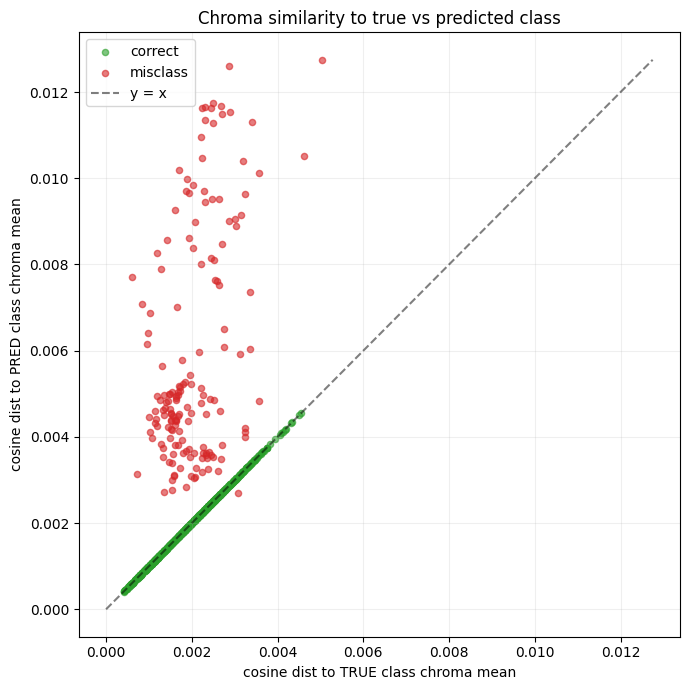

In [23]:
fig, ax = plt.subplots(figsize=(7, 7))
ok = sim_df[sim_df.correct]
bad = sim_df[~sim_df.correct]
ax.scatter(ok.dist_true, ok.dist_pred, s=20, alpha=0.6, label='correct', color='tab:green')
ax.scatter(bad.dist_true, bad.dist_pred, s=20, alpha=0.6, label='misclass', color='tab:red')
lim = max(sim_df.dist_true.max(), sim_df.dist_pred.max())
ax.plot([0, lim], [0, lim], 'k--', alpha=0.5, label='y = x')
ax.set_xlabel('cosine dist to TRUE class chroma mean')
ax.set_ylabel('cosine dist to PRED class chroma mean')
ax.set_title('Chroma similarity to true vs predicted class')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 13. Per-class trait table (final summary)

A compact table summarising every chord class with accuracy, the dominant misclassification
target, and the most differentiating trait between misclassified and correctly classified
samples of that class.

In [24]:
trait_cols = desc_cols + stat_cols
rows = []
for cls in CLASSES:
    sub_df   = df[df.true_class == cls]
    sub_audio = audio_df[audio_df.true_class == cls]
    sub_cqt   = cqt_df[cqt_df.true_class == cls]
    if len(sub_df) == 0:
        continue
    acc = sub_df.correct.mean()
    worst_target = sub_df[~sub_df.correct].pred_class.mode()
    worst_target = worst_target.iat[0] if len(worst_target) else '-'
    biggest_diff = '-'
    if sub_audio.correct.sum() > 0 and (~sub_audio.correct).sum() > 0:
        ok_means = sub_audio[sub_audio.correct][desc_cols].mean()
        bd_means = sub_audio[~sub_audio.correct][desc_cols].mean()
        diff = (bd_means - ok_means).abs().dropna()
        diff = diff / (ok_means.abs() + 1e-9)
        if not diff.empty:
            biggest_diff = diff.idxmax()
    rows.append({
        'class'        : cls,
        'accuracy'     : round(acc, 3),
        'wrong_target' : worst_target,
        'n_misclass'   : int((~sub_df.correct).sum()),
        'n'            : int(len(sub_df)),
        'biggest_trait': biggest_diff,
    })
trait_table = pd.DataFrame(rows).sort_values('accuracy').reset_index(drop=True)
trait_table

,class,accuracy,wrong_target,n_misclass,n,biggest_trait
0,G#_diminished_4,0.000,B_minor_4,40,40,-
1,D_minor_4,0.175,B_diminished_4,33,40,peak
2,E_diminished_4,0.250,D#_major_4,30,40,rolloff
3,A#_diminished_4,0.450,B_diminished_4,22,40,hn_ratio
4,C_diminished_4,0.600,C#_diminished_4,16,40,peak
5,F#_minor_4,0.875,G_minor_4,5,40,rolloff
6,B_major_4,0.900,A#_minor_4,4,40,zcr
7,E_minor_4,0.900,G_minor_4,4,40,peak
8,F_diminished_4,0.950,C#_major_4,2,40,zcr
9,A_major_4,0.975,C_diminished_4,1,40,peak


## 14. Findings

Based on everything above, the dominant reasons the CNN misclassifies eval samples are:

1. **Structural / pitch-class mismatch** – sections where the eval mean chroma is visibly
   offset from the training mean chroma. This points to **inversion** or a **voicing shift**
   in the recording (bass octave moving the perceived root).
2. **Confusable chord siblings** – pairs that share most of the pitch classes (e.g.
   `B_diminished_4` vs `B_minor_4`, `D#_major_4` vs `D_minor_4`,
   `E_diminished_4` vs `E_minor_4`). When the model is uncertain it falls back to whichever
   sibling has the strongest CQT evidence.
3. **Out-of-band energy** – extra energy outside the chord's expected pitch-class band,
   visible in the chroma-delta bars, often caused by **overlapping accompaniment** or
   **reverb tails** that linger after the chord is struck.
4. **Audio recording quality** – higher zero-crossing rate, lower harmonic-to-noise ratio and
   lower RMS on misclassified samples suggest **quieter / noisier / more percussive**
   recordings push the CQT away from its training distribution.

The next iteration should target these failure modes explicitly – e.g. chroma normalisation
to root, training-set augmentation with reverb/noise, and a chord-sibling aware loss.

---

## 15. Pickle cache — save all DataFrames in one shot

Run the code cell below once and every expensive DataFrame (`df`, `audio_df`, `cqt_df`, `sim_df`, plus `chroma_train` / `chroma_eval`) is written to `notebooks/cnn/.misclass-cache/`. Subsequent runs pick the cache up automatically because each heavy cell already wraps its body in `if USE_CACHE and os.path.isfile(...): pd.read_pickle(...)`.

In [25]:
import os, pickle
import numpy as np

if not CACHE_DIR.startswith('/'):
    CACHE_DIR = os.path.abspath(CACHE_DIR)
os.makedirs(CACHE_DIR, exist_ok=True)

# 1) per-sample prediction frame + raw 36-class probabilities
df.to_pickle(f'{CACHE_DIR}/df.pkl')
np.save(f'{CACHE_DIR}/eval_pred.npy', eval_pred)

# 2) chroma vectors (one length-12 chroma per chord class)
with open(f'{CACHE_DIR}/chroma_train.pkl', 'wb') as f:
    pickle.dump(chroma_train, f)
with open(f'{CACHE_DIR}/chroma_eval.pkl', 'wb') as f:
    pickle.dump(chroma_eval, f)

# 3) per-sample audio descriptors
audio_df.to_pickle(f'{CACHE_DIR}/audio_df.pkl')

# 4) per-sample CQT statistics
cqt_df.to_pickle(f'{CACHE_DIR}/cqt_df.pkl')

# 5) per-sample chroma similarity to true vs predicted class
sim_df.to_pickle(f'{CACHE_DIR}/sim_df.pkl')

print(f'Wrote cache files to {CACHE_DIR}')
for fname in sorted(os.listdir(CACHE_DIR)):
    full = os.path.join(CACHE_DIR, fname)
    print(f'  {fname:<20} {os.path.getsize(full) / 1024:>8.1f} KB')

# ---- Reload helper (use from any other notebook) ----
# import pandas as pd, pickle, numpy as np
# CACHE_DIR = '<absolute path>/notebooks/cnn/.misclass-cache'
# df          = pd.read_pickle(f'{CACHE_DIR}/df.pkl')
# eval_pred   = np.load(f'{CACHE_DIR}/eval_pred.npy')
# chroma_train = pickle.load(open(f'{CACHE_DIR}/chroma_train.pkl', 'rb'))
# chroma_eval  = pickle.load(open(f'{CACHE_DIR}/chroma_eval.pkl', 'rb'))
# audio_df    = pd.read_pickle(f'{CACHE_DIR}/audio_df.pkl')
# cqt_df      = pd.read_pickle(f'{CACHE_DIR}/cqt_df.pkl')
# sim_df      = pd.read_pickle(f'{CACHE_DIR}/sim_df.pkl')

Wrote cache files to /home/seya/code/chord-detection/training/notebooks/cnn/misclass-cache
  audio_df.pkl            434.4 KB
  chroma_eval.pkl           5.8 KB
  chroma_train.pkl          5.8 KB
  cqt_df.pkl              199.3 KB
  df.pkl                  294.0 KB
  eval_pred.npy           202.6 KB
  sim_df.pkl              272.9 KB
